In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r "/content/drive/MyDrive/stuff_model/data/" "/content/"

In [3]:
!cp -r "/content/drive/MyDrive/stuff_model/model_storage/" "/content/"

In [4]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, root_mean_squared_error
import joblib

# Analysis libraries
import shap
from scipy.stats import zscore
from scipy import stats
from tqdm.notebook import tqdm

In [5]:
%matplotlib inline

In [6]:
# Load the trained LightGBM model
filename = './model_storage/lightgbm_model.joblib'
lgb_model = joblib.load(filename)

In [7]:
def calculate_stuff_plus(df, ref_mean=None, ref_std=None):
    """
    Calculate Stuff+ on 20-80 scouting scale across all pitch types.

    Args:
        df: DataFrame containing 'y_pred'
        ref_mean: Optional reference mean from training data (for inference stability)
        ref_std: Optional reference std from training data
    """
    preds = df['y_pred'].values

    if ref_mean is not None and ref_std is not None:
        # Use fixed scaling statistics (safe for inference/subsets)
        z_scores = (preds - ref_mean) / ref_std
    else:
        # Use batch statistics (analysis mode)
        # Z-score across ALL pitches in the current dataframe
        z_scores = zscore(preds)

    # Scale to 20-80: 50 is average, each 10 points = 1 std dev
    stuff_plus = 50 - z_scores * 10

    # Force results within 20-80 range
    stuff_plus = np.clip(stuff_plus, 20, 80)

    df['stuff_plus'] = stuff_plus
    return df

In [8]:
# Load 2025 test data
data_2025 = pl.read_csv('./data/test_data_2025.csv')

# Convert categorical columns
data_2025 = data_2025.with_columns([
    pl.col("p_throws").cast(pl.Categorical),
    pl.col("stand").cast(pl.Categorical)
])

# Define features (same as in training)
features = ['release_speed',
            'release_spin_rate',
            'spin_axis',
            'release_extension',
            'az',
            'ax',
            'release_pos_x',
            'release_pos_z',
            'speed_diff',
            'az_diff',
            'ax_diff',
            'stand',
            'p_throws']

# Drop nulls and convert to pandas
data_2025 = data_2025.drop_nulls(subset=features)
data_2025 = data_2025.to_pandas()

# Ensure categorical columns are properly typed
categorical_cols = ['p_throws', 'stand']
for col in categorical_cols:
    if col in data_2025.columns:
        data_2025[col] = data_2025[col].astype('category')

print(f"Loaded {len(data_2025):,} pitches from 2025")
print(f"Date range: {data_2025['game_date'].min()} to {data_2025['game_date'].max()}")

Loaded 727,784 pitches from 2025
Date range: 2025-03-18 to 2025-09-28


In [9]:
# Generate predictions and calculate Stuff+
data_2025['y_pred'] = lgb_model.predict(data_2025[features])

# Use 2025 data statistics for scaling (centered on 2025 league average)
# This makes Stuff+ 50 = 2025 average, easier for leaderboard interpretation
ref_mean = data_2025['y_pred'].mean()
ref_std = data_2025['y_pred'].std()

print(f"2025 Scaling Reference: Mean={ref_mean:.6f}, Std={ref_std:.6f}")

data_2025 = calculate_stuff_plus(data_2025, ref_mean=ref_mean, ref_std=ref_std)

print(f"Predictions generated for {len(data_2025):,} pitches")
print(f"Stuff+ range: {data_2025['stuff_plus'].min():.1f} to {data_2025['stuff_plus'].max():.1f}")
print(f"Stuff+ mean: {data_2025['stuff_plus'].mean():.2f}")

2025 Scaling Reference: Mean=-0.000929, Std=0.007530
Predictions generated for 727,784 pitches
Stuff+ range: 20.0 to 80.0
Stuff+ mean: 50.10


In [10]:
# Helper function to determine pitcher role (SP vs RP)
# We'll use a simple heuristic: if a pitcher averages <2 innings per game, they're a reliever
def classify_pitcher_role(df):
    """
    Classify pitchers as SP (Starting Pitcher) or RP (Relief Pitcher)
    Based on average pitches per game appearance
    """
    pitcher_stats = df.groupby('pitcher').agg(
        total_pitches=('pitch_type', 'count'),
        total_games=('game_date', 'nunique'),
        player_name=('player_name', 'first')
    ).reset_index()

    pitcher_stats['pitches_per_game'] = pitcher_stats['total_pitches'] / pitcher_stats['total_games']

    # Threshold: SPs typically throw 80+ pitches per game, RPs throw fewer
    # Using 60 as a reasonable cutoff
    pitcher_stats['role'] = pitcher_stats['pitches_per_game'].apply(
        lambda x: 'SP' if x >= 60 else 'RP'
    )

    return pitcher_stats[['pitcher', 'player_name', 'role']]

# Classify pitchers
pitcher_roles = classify_pitcher_role(data_2025)

# Merge role back to main dataframe
data_2025 = data_2025.merge(pitcher_roles[['pitcher', 'role']], on='pitcher', how='left')

print("Pitcher role distribution:")
print(pitcher_roles['role'].value_counts())
print(f"\nSample SP pitchers:")
print(pitcher_roles[pitcher_roles['role'] == 'SP']['player_name'].head(10).tolist())
print(f"\nSample RP pitchers:")
print(pitcher_roles[pitcher_roles['role'] == 'RP']['player_name'].head(10).tolist())

Pitcher role distribution:
role
RP    790
SP    253
Name: count, dtype: int64

Sample SP pitchers:
['Verlander, Justin', 'Hill, Rich', 'Morton, Charlie', 'Scherzer, Max', 'Carrasco, Carlos', 'Kershaw, Clayton', 'Miley, Wade', 'Quintana, Jose', 'Gibson, Kyle', 'Darvish, Yu']

Sample RP pitchers:
['Jansen, Kenley', 'Chavez, Jesse', 'Martin, Chris', 'Wilson, Justin', 'García, Luis', 'Stock, Robert', 'Yates, Kirby', 'Ottavino, Adam', 'Rojas, Miguel', 'Robertson, David']


In [11]:
## Starting Pitcher (SP) Leaderboard

# Filter for starting pitchers with minimum 200 pitches
min_pitches = 200

sp_data = data_2025[data_2025['role'] == 'SP']

sp_leaderboard = sp_data.groupby(['pitcher', 'player_name']).agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
).reset_index()

# Filter by minimum pitches
sp_leaderboard = sp_leaderboard[sp_leaderboard['pitches'] >= min_pitches]

# Sort by Stuff+
sp_leaderboard = sp_leaderboard.sort_values('avg_stuff_plus', ascending=False).reset_index(drop=True)

# Add rank
sp_leaderboard['rank'] = range(1, len(sp_leaderboard) + 1)

print("=" * 70)
print("TOP 20 STARTING PITCHERS - 2025 STUFF+ LEADERBOARD")
print("=" * 70)
print(f"(Minimum {min_pitches} pitches)")
print()
print(sp_leaderboard[['rank', 'player_name', 'avg_stuff_plus', 'pitches']].head(20).to_string(index=False))
print()
print(f"Total qualified SPs: {len(sp_leaderboard)}")

TOP 20 STARTING PITCHERS - 2025 STUFF+ LEADERBOARD
(Minimum 200 pitches)

 rank         player_name  avg_stuff_plus  pitches
    1      Yesavage, Trey       61.531472      239
    2      Greene, Hunter       61.435074     1832
    3  Misiorowski, Jacob       58.318336     1164
    4     Chandler, Bubba       57.859815      395
    5          Boyle, Joe       57.464095      932
    6       deGrom, Jacob       56.922846     2741
    7      Glasnow, Tyler       56.695140     1532
    8         Pérez, Eury       56.643118     1673
    9      Burnes, Corbin       56.285710     1009
   10        Leiter, Jack       56.270220     2637
   11     Valdez, Framber       56.224418     2977
   12        Cease, Dylan       56.025300     3117
   13       Skubal, Tarik       55.948984     2849
   14       McLean, Nolan       55.675117      739
   15       Wheeler, Zack       55.646037     2463
   16       Morales, Luis       55.466541      821
   17        Pepiot, Ryan       55.239937     2640
   18   

In [12]:
## Relief Pitcher (RP) Leaderboard

# Filter for relief pitchers with minimum 100 pitches (RPs throw less)
min_pitches_rp = 100

rp_data = data_2025[data_2025['role'] == 'RP']

rp_leaderboard = rp_data.groupby(['pitcher', 'player_name']).agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
).reset_index()

# Filter by minimum pitches
rp_leaderboard = rp_leaderboard[rp_leaderboard['pitches'] >= min_pitches_rp]

# Sort by Stuff+
rp_leaderboard = rp_leaderboard.sort_values('avg_stuff_plus', ascending=False).reset_index(drop=True)

# Add rank
rp_leaderboard['rank'] = range(1, len(rp_leaderboard) + 1)

print("=" * 70)
print("TOP 20 RELIEF PITCHERS - 2025 STUFF+ LEADERBOARD")
print("=" * 70)
print(f"(Minimum {min_pitches_rp} pitches)")
print()
print(rp_leaderboard[['rank', 'player_name', 'avg_stuff_plus', 'pitches']].head(20).to_string(index=False))
print()
print(f"Total qualified RPs: {len(rp_leaderboard)}")

TOP 20 RELIEF PITCHERS - 2025 STUFF+ LEADERBOARD
(Minimum 100 pitches)

 rank       player_name  avg_stuff_plus  pitches
    1   Clase, Emmanuel       66.558549      775
    2     Helsley, Ryan       65.438619     1012
    3 Montgomery, Mason       64.397136      876
    4    Megill, Trevor       64.092151      774
    5      Burns, Chase       63.421357      765
    6     Taylor, Grant       63.107050      610
    7     Miller, Mason       62.881418     1000
    8   Bautista, Félix       62.490962      627
    9  Chapman, Aroldis       61.515871      932
   10      Jax, Griffin       61.451824     1124
   11  Rodríguez, Randy       61.413873      859
   12      Ashby, Aaron       60.887008     1033
   13 Estrada, Jeremiah       60.875763     1251
   14   Williams, Devin       60.678912     1146
   15     Bigge, Hunter       60.591982      243
   16      Stanek, Ryne       60.116127     1087
   17   Fairbanks, Pete       60.070112      982
   18  Kerkering, Orion       59.900354     11

In [13]:
## Individual Pitch Leaderboard (e.g., Fastballs, Skubal's Fastball)

# Minimum pitches for individual pitch type analysis
min_pitch_count = 50

# Create pitch-level leaderboard (pitcher + pitch_type)
pitch_leaderboard = data_2025.groupby(['pitcher', 'player_name', 'pitch_type']).agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
).reset_index()

# Filter by minimum pitches
pitch_leaderboard = pitch_leaderboard[pitch_leaderboard['pitches'] >= min_pitch_count]

# Sort by Stuff+
pitch_leaderboard = pitch_leaderboard.sort_values('avg_stuff_plus', ascending=False).reset_index(drop=True)

# Add rank
pitch_leaderboard['rank'] = range(1, len(pitch_leaderboard) + 1)

print("=" * 80)
print("TOP 20 INDIVIDUAL PITCHES - 2025 STUFF+ LEADERBOARD")
print("=" * 80)
print(f"(Minimum {min_pitch_count} pitches of that type)")
print()
print(pitch_leaderboard[['rank', 'player_name', 'pitch_type', 'avg_stuff_plus', 'pitches']].head(20).to_string(index=False))
print()
print(f"Total qualified pitch-type combinations: {len(pitch_leaderboard)}")

TOP 20 INDIVIDUAL PITCHES - 2025 STUFF+ LEADERBOARD
(Minimum 50 pitches of that type)

 rank       player_name pitch_type  avg_stuff_plus  pitches
    1     Peguero, Joel         SL       75.544882      107
    2      Ashby, Aaron         CU       72.536673      273
    3    Yesavage, Trey         FS       71.310727       63
    4     Helsley, Ryan         SL       70.368586      475
    5       Leahy, Kyle         ST       69.829050      188
    6      Jax, Griffin         ST       69.800412      487
    7      Burns, Chase         SL       68.651462      265
    8  Ashcraft, Graham         SL       68.626487      483
    9   Clase, Emmanuel         FC       67.916587      536
   10       Sims, Lucas         ST       67.710720      122
   11      Miller, Erik         SI       67.447870       92
   12   Williams, Devin         CH       66.726991      599
   13      Stanek, Ryne         SL       66.688030      227
   14  Kerkering, Orion         ST       66.233336      539
   15   Bauti

In [14]:
## Pitch Type Leaderboards

# Create leaderboards for major pitch types
pitch_types = ['FF', 'SL', 'CH', 'CU', 'SI', 'FC']
min_pitch_count = 50

for pt in pitch_types:
    pt_data = pitch_leaderboard[pitch_leaderboard['pitch_type'] == pt].copy()

    if len(pt_data) > 0:
        # Add percentile
        pt_data['percentile'] = pt_data['avg_stuff_plus'].rank(pct=True) * 100

        print("=" * 80)
        if pt == 'FF':
            print(f"TOP 15 FOUR-SEAM FASTBALLS - 2025 STUFF+ LEADERBOARD")
        elif pt == 'SL':
            print(f"TOP 15 SLIDERS - 2025 STUFF+ LEADERBOARD")
        elif pt == 'CH':
            print(f"TOP 15 CHANGEUPS - 2025 STUFF+ LEADERBOARD")
        elif pt == 'CU':
            print(f"TOP 15 CURVEBALLS - 2025 STUFF+ LEADERBOARD")
        elif pt == 'SI':
            print(f"TOP 15 SINKERS - 2025 STUFF+ LEADERBOARD")
        elif pt == 'FC':
            print(f"TOP 15 CUTTERS - 2025 STUFF+ LEADERBOARD")
        print("=" * 80)
        print(f"(Minimum {min_pitch_count} pitches)")
        print()
        print(pt_data[['rank', 'player_name', 'avg_stuff_plus', 'pitches']].head(15).to_string(index=False))
        print()
        print(f"Total qualified pitchers: {len(pt_data)}")
        print()

TOP 15 FOUR-SEAM FASTBALLS - 2025 STUFF+ LEADERBOARD
(Minimum 50 pitches)

 rank        player_name  avg_stuff_plus  pitches
   34     Megill, Trevor       64.309106      469
   41  Estrada, Jeremiah       63.901934      710
   42  Montgomery, Mason       63.807559      583
   47      Miller, Mason       63.526431      525
   50 Henriquez, Edgardo       63.068428       70
   53      Helsley, Ryan       62.629384      460
   58      Taylor, Grant       62.394036      338
   70   Rodríguez, Randy       62.072499      484
   75      Maxwell, Zach       61.572903       95
   94       Burns, Chase       61.022706      442
  105   Chapman, Aroldis       60.681924      369
  110        Pérez, Eury       60.591468      862
  127     Greene, Hunter       60.137348      986
  132   Henriquez, Ronny       60.033770      344
  141       Díaz, Alexis       59.787799      224

Total qualified pitchers: 606

TOP 15 SLIDERS - 2025 STUFF+ LEADERBOARD
(Minimum 50 pitches)

 rank       player_name  avg_s

In [24]:
## Splitter (FS) Analysis

# Filter for splitters
splitter_data = data_2025[data_2025['pitch_type'] == 'FS']

print("=" * 80)
print("SPLITTER (FS) ANALYSIS - 2025")
print("=" * 80)
print()

if len(splitter_data) > 0:
    print(f"Total splitters thrown: {len(splitter_data):,}")
    print(f"Average Stuff+: {splitter_data['stuff_plus'].mean():.2f}")
    print(f"Std Dev: {splitter_data['stuff_plus'].std():.2f}")
    print(f"Min Stuff+: {splitter_data['stuff_plus'].min():.2f}")
    print(f"Max Stuff+: {splitter_data['stuff_plus'].max():.2f}")
    print()

    # Get splitter leaderboard
    min_splitter_count = 30  # Lower threshold since splitters are less common

    splitter_leaderboard = splitter_data.groupby(['pitcher', 'player_name']).agg(
        avg_stuff_plus=('stuff_plus', 'mean'),
        pitches=('stuff_plus', 'count')
    ).reset_index()

    splitter_leaderboard = splitter_leaderboard[splitter_leaderboard['pitches'] >= min_splitter_count]
    splitter_leaderboard = splitter_leaderboard.sort_values('avg_stuff_plus', ascending=False).reset_index(drop=True)
    splitter_leaderboard['rank'] = range(1, len(splitter_leaderboard) + 1)

    print("=" * 80)
    print(f"TOP 20 SPLITTERS - 2025 STUFF+ LEADERBOARD")
    print("=" * 80)
    print(f"(Minimum {min_splitter_count} pitches)")
    print()
    print(splitter_leaderboard[['rank', 'player_name', 'avg_stuff_plus', 'pitches']].head(20).to_string(index=False))
    print()
    print(f"Total qualified pitchers: {len(splitter_leaderboard)}")
    print()

    # Compare splitter to other pitch types
    print("=" * 80)
    print("SPLITTER EFFECTIVENESS COMPARISON")
    print("=" * 80)
    print()

    pitch_comparison = data_2025.groupby('pitch_type').agg(
        avg_stuff_plus=('stuff_plus', 'mean'),
        pitches=('stuff_plus', 'count')
    ).sort_values('avg_stuff_plus', ascending=False).reset_index()

    pitch_comparison['rank'] = range(1, len(pitch_comparison) + 1)

    print("Average Stuff+ by Pitch Type:")
    print(pitch_comparison.to_string(index=False))
    print()

    splitter_rank = pitch_comparison[pitch_comparison['pitch_type'] == 'FS']['rank'].values
    if len(splitter_rank) > 0:
        print(f"Splitter ranks #{splitter_rank[0]} out of {len(pitch_comparison)} pitch types by average Stuff+")
else:
    print("No splitters found in 2025 data")

SPLITTER (FS) ANALYSIS - 2025

Total splitters thrown: 24,040
Average Stuff+: 49.99
Std Dev: 8.46
Min Stuff+: 20.00
Max Stuff+: 80.00

TOP 20 SPLITTERS - 2025 STUFF+ LEADERBOARD
(Minimum 30 pitches)

 rank         player_name  avg_stuff_plus  pitches
    1      Yesavage, Trey       71.310727       63
    2        Stanek, Ryne       64.027179      131
    3    Chapman, Aroldis       62.685560      104
    4        Duran, Jhoan       62.336239      452
    5         Smith, Cade       62.113122      255
    6     Halvorsen, Seth       61.465469      170
    7          Boyle, Joe       60.483785      152
    8      Ohtani, Shohei       58.682059       35
    9        Skenes, Paul       58.391158      417
   10        Melton, Troy       58.386531       53
   11      Greene, Hunter       57.446158      198
   12       Holman, Grant       57.157108      144
   13    Palencia, Daniel       56.739775       39
   14 Yamamoto, Yoshinobu       56.452016      710
   15     Bautista, Félix       55.

In [25]:
## Sweeper (ST) Analysis

# Filter for sweepers
sweeper_data = data_2025[data_2025['pitch_type'] == 'ST']

print("=" * 80)
print("SWEEPER (ST) ANALYSIS - 2025")
print("=" * 80)
print()

if len(sweeper_data) > 0:
    print(f"Total sweepers thrown: {len(sweeper_data):,}")
    print(f"Average Stuff+: {sweeper_data['stuff_plus'].mean():.2f}")
    print(f"Std Dev: {sweeper_data['stuff_plus'].std():.2f}")
    print(f"Min Stuff+: {sweeper_data['stuff_plus'].min():.2f}")
    print(f"Max Stuff+: {sweeper_data['stuff_plus'].max():.2f}")
    print()

    # Get sweeper leaderboard
    min_sweeper_count = 30  # Lower threshold since sweepers are less common

    sweeper_leaderboard = sweeper_data.groupby(['pitcher', 'player_name']).agg(
        avg_stuff_plus=('stuff_plus', 'mean'),
        pitches=('stuff_plus', 'count')
    ).reset_index()

    sweeper_leaderboard = sweeper_leaderboard[sweeper_leaderboard['pitches'] >= min_sweeper_count]
    sweeper_leaderboard = sweeper_leaderboard.sort_values('avg_stuff_plus', ascending=False).reset_index(drop=True)
    sweeper_leaderboard['rank'] = range(1, len(sweeper_leaderboard) + 1)

    print("=" * 80)
    print(f"TOP 20 SWEEPERS - 2025 STUFF+ LEADERBOARD")
    print("=" * 80)
    print(f"(Minimum {min_sweeper_count} pitches)")
    print()
    print(sweeper_leaderboard[['rank', 'player_name', 'avg_stuff_plus', 'pitches']].head(20).to_string(index=False))
    print()
    print(f"Total qualified pitchers: {len(sweeper_leaderboard)}")
    print()

    # Compare sweeper to other pitch types
    print("=" * 80)
    print("SWEEPER EFFECTIVENESS COMPARISON")
    print("=" * 80)
    print()

    pitch_comparison = data_2025.groupby('pitch_type').agg(
        avg_stuff_plus=('stuff_plus', 'mean'),
        pitches=('stuff_plus', 'count')
    ).sort_values('avg_stuff_plus', ascending=False).reset_index()

    pitch_comparison['rank'] = range(1, len(pitch_comparison) + 1)

    print("Average Stuff+ by Pitch Type:")
    print(pitch_comparison.to_string(index=False))
    print()

    sweeper_rank = pitch_comparison[pitch_comparison['pitch_type'] == 'ST']['rank'].values
    if len(sweeper_rank) > 0:
        print(f"Sweeper ranks #{sweeper_rank[0]} out of {len(pitch_comparison)} pitch types by average Stuff+")
else:
    print("No sweepers found in 2025 data")

SWEEPER (ST) ANALYSIS - 2025

Total sweepers thrown: 50,855
Average Stuff+: 53.97
Std Dev: 9.14
Min Stuff+: 20.00
Max Stuff+: 80.00

TOP 20 SWEEPERS - 2025 STUFF+ LEADERBOARD
(Minimum 30 pitches)

 rank         player_name  avg_stuff_plus  pitches
    1         Leahy, Kyle       69.829050      188
    2        Jax, Griffin       69.800412      487
    3         Sims, Lucas       67.710720      122
    4    Kerkering, Orion       66.233336      539
    5     Garcia, Brandyn       65.615291       87
    6      Casparius, Ben       65.452857      416
    7        Keller, Brad       65.389062      161
    8        García, Yimi       65.312441       64
    9    Wesneski, Hayden       64.668127      125
   10    Armstrong, Shawn       64.334840      255
   11      Stewart, Brock       64.285256       87
   12      Slaten, Justin       64.015302       59
   13        Strowd, Kade       63.970526       51
   14       Morales, Luis       63.743711      218
   15     Schlittler, Cam       63.063

Plotting 10 pitch types with 1000+ pitches
Pitch types: ['FF', 'SI', 'SL', 'CH', 'FC', 'CU', 'ST', 'FS', 'KC', 'SV']



/tmp/ipython-input-2807891702.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(pitch_type_stuff, labels=sorted_pitch_types, patch_artist=True)


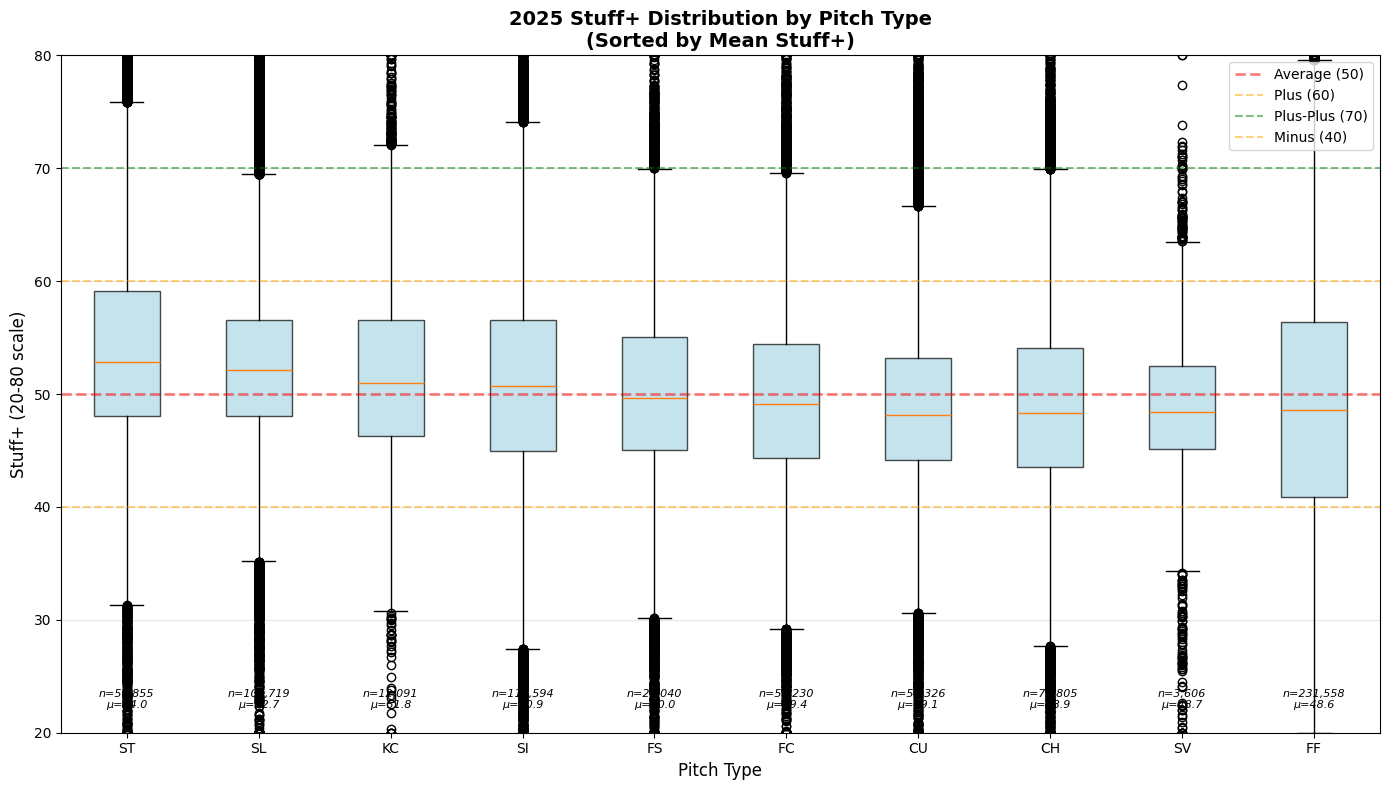


PITCH TYPE SUMMARY STATISTICS

            mean_stuff  median_stuff  std_stuff   count
pitch_type                                             
ST           53.969582     52.804116   9.142556   50855
SL           52.691975     52.101375   7.199383  107719
KC           51.843340     50.944582   7.778523   12091
SI           50.868315     50.675178   8.922464  113594
FS           49.991065     49.687993   8.463775   24040
FC           49.402660     49.134842   7.783956   55230
CU           49.094329     48.143446   7.852689   51326
CH           48.888848     48.316531   8.148936   74805
SV           48.728771     48.367412   6.798556    3606
FF           48.638490     48.616168  10.763743  231558
FO           47.615485     47.735646   4.643720     539
SC           42.565451     44.810390   4.000626       7
UN           41.252568     41.342332   9.954694       3
PO           39.037162     38.636013  10.100958      55
CS           37.385565     39.806255  10.913878     359
KN           34.

In [16]:
## Stuff+ Distribution by Pitch Type - Boxplot Visualization

# Get all pitch types with sufficient data
pitch_type_counts = data_2025['pitch_type'].value_counts()
# Include pitch types with at least 1000 pitches for meaningful distributions
pitch_types_to_plot = pitch_type_counts[pitch_type_counts >= 1000].index.tolist()

print(f"Plotting {len(pitch_types_to_plot)} pitch types with 1000+ pitches")
print(f"Pitch types: {pitch_types_to_plot}")
print()

# Create boxplot data
pitch_type_stuff = [data_2025[data_2025['pitch_type'] == pt]['stuff_plus'].values
                    for pt in pitch_types_to_plot]

# Calculate mean Stuff+ for each pitch type for sorting
pitch_type_means = [(pt, data_2025[data_2025['pitch_type'] == pt]['stuff_plus'].mean())
                    for pt in pitch_types_to_plot]
pitch_type_means.sort(key=lambda x: x[1], reverse=True)
sorted_pitch_types = [pt for pt, _ in pitch_type_means]

# Recreate boxplot data in sorted order
pitch_type_stuff = [data_2025[data_2025['pitch_type'] == pt]['stuff_plus'].values
                    for pt in sorted_pitch_types]

# Create figure
plt.figure(figsize=(14, 8))

bp = plt.boxplot(pitch_type_stuff, labels=sorted_pitch_types, patch_artist=True)

# Color the boxes
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

# Add reference lines
plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='Average (50)', linewidth=2)
plt.axhline(60, color='orange', linestyle='--', alpha=0.5, label='Plus (60)', linewidth=1.5)
plt.axhline(70, color='green', linestyle='--', alpha=0.5, label='Plus-Plus (70)', linewidth=1.5)
plt.axhline(40, color='orange', linestyle='--', alpha=0.5, label='Minus (40)', linewidth=1.5)

plt.ylabel('Stuff+ (20-80 scale)', fontsize=12)
plt.xlabel('Pitch Type', fontsize=12)
plt.title('2025 Stuff+ Distribution by Pitch Type\n(Sorted by Mean Stuff+)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(20, 80)

# Add count annotations
for i, pt in enumerate(sorted_pitch_types):
    count = len(data_2025[data_2025['pitch_type'] == pt])
    mean_val = data_2025[data_2025['pitch_type'] == pt]['stuff_plus'].mean()
    plt.text(i+1, 22, f'n={count:,}\nμ={mean_val:.1f}',
             ha='center', va='bottom', fontsize=8, style='italic')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 80)
print("PITCH TYPE SUMMARY STATISTICS")
print("=" * 80)
print()
summary_df = data_2025.groupby('pitch_type').agg(
    mean_stuff=('stuff_plus', 'mean'),
    median_stuff=('stuff_plus', 'median'),
    std_stuff=('stuff_plus', 'std'),
    count=('stuff_plus', 'count')
).sort_values('mean_stuff', ascending=False)
print(summary_df.to_string())

In [17]:
## 1. Pitcher Arsenal Analysis

print("=" * 80)
print("PITCHER ARSENAL ANALYSIS - 2025")
print("=" * 80)
print()

# Calculate arsenal metrics for each pitcher
arsenal_analysis = data_2025.groupby(['pitcher', 'player_name', 'pitch_type']).agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
).reset_index()

# Filter for pitches with at least 20 thrown
arsenal_analysis = arsenal_analysis[arsenal_analysis['pitches'] >= 20]

# Count number of quality pitches per pitcher (Stuff+ >= 50)
quality_pitches = arsenal_analysis[arsenal_analysis['avg_stuff_plus'] >= 50].groupby('pitcher').size().reset_index(name='quality_pitch_count')

# Get overall pitcher stats
pitcher_arsenal = arsenal_analysis.groupby(['pitcher', 'player_name']).agg(
    pitch_types=('pitch_type', 'count'),
    weighted_avg_stuff=('avg_stuff_plus', 'mean'),
    best_pitch_stuff=('avg_stuff_plus', 'max'),
    total_pitches=('pitches', 'sum')
).reset_index()

# Merge quality pitch count
pitcher_arsenal = pitcher_arsenal.merge(quality_pitches, on='pitcher', how='left')
pitcher_arsenal['quality_pitch_count'] = pitcher_arsenal['quality_pitch_count'].fillna(0)

# Filter for pitchers with 200+ pitches
pitcher_arsenal = pitcher_arsenal[pitcher_arsenal['total_pitches'] >= 200]

# Calculate "Arsenal Score" - combination of depth and quality
pitcher_arsenal['arsenal_score'] = (
    pitcher_arsenal['weighted_avg_stuff'] * 0.6 +
    pitcher_arsenal['quality_pitch_count'] * 3 +
    pitcher_arsenal['pitch_types'] * 2
)

pitcher_arsenal = pitcher_arsenal.sort_values('arsenal_score', ascending=False).reset_index(drop=True)
pitcher_arsenal['rank'] = range(1, len(pitcher_arsenal) + 1)

print("TOP 20 PITCHERS BY ARSENAL QUALITY")
print("(Arsenal Score = Weighted Avg Stuff * 0.6 + Quality Pitches * 3 + Pitch Types * 2)")
print()
print(pitcher_arsenal[['rank', 'player_name', 'arsenal_score', 'weighted_avg_stuff',
                       'quality_pitch_count', 'pitch_types', 'best_pitch_stuff']].head(20).to_string(index=False))
print()

# One-pitch wonders vs multi-pitch aces
print("\n" + "=" * 80)
print("ONE-PITCH WONDERS (High best pitch, few quality pitches)")
print("=" * 80)
one_pitch = pitcher_arsenal[
    (pitcher_arsenal['best_pitch_stuff'] >= 60) &
    (pitcher_arsenal['quality_pitch_count'] <= 1)
].sort_values('best_pitch_stuff', ascending=False).head(10)
print(one_pitch[['player_name', 'best_pitch_stuff', 'quality_pitch_count', 'pitch_types']].to_string(index=False))

print("\n" + "=" * 80)
print("MULTI-PITCH ACES (3+ quality pitches with Stuff+ >= 50)")
print("=" * 80)
multi_pitch = pitcher_arsenal[
    pitcher_arsenal['quality_pitch_count'] >= 3
].sort_values('weighted_avg_stuff', ascending=False).head(10)
print(multi_pitch[['player_name', 'weighted_avg_stuff', 'quality_pitch_count', 'pitch_types']].to_string(index=False))

PITCHER ARSENAL ANALYSIS - 2025

TOP 20 PITCHERS BY ARSENAL QUALITY
(Arsenal Score = Weighted Avg Stuff * 0.6 + Quality Pitches * 3 + Pitch Types * 2)

 rank           player_name  arsenal_score  weighted_avg_stuff  quality_pitch_count  pitch_types  best_pitch_stuff
    1            Abel, Mick      62.582212           54.303687                  6.0            6         57.850475
    2        Ohtani, Shohei      61.823293           54.705489                  5.0            7         60.903653
    3           Leahy, Kyle      60.033797           55.056329                  5.0            6         69.829050
    4       Coulombe, Danny      59.955752           58.259587                  5.0            5         63.465633
    5           Gray, Sonny      59.943314           51.572190                  5.0            7         60.717560
    6      Henriquez, Ronny      59.926997           58.211662                  5.0            5         60.118301
    7         Wheeler, Zack      59.894754 

VELOCITY vs. STUFF+ ANALYSIS - 2025

Correlation between velocity and Stuff+ (Fastballs): 0.338



/tmp/ipython-input-1501528018.py:62: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


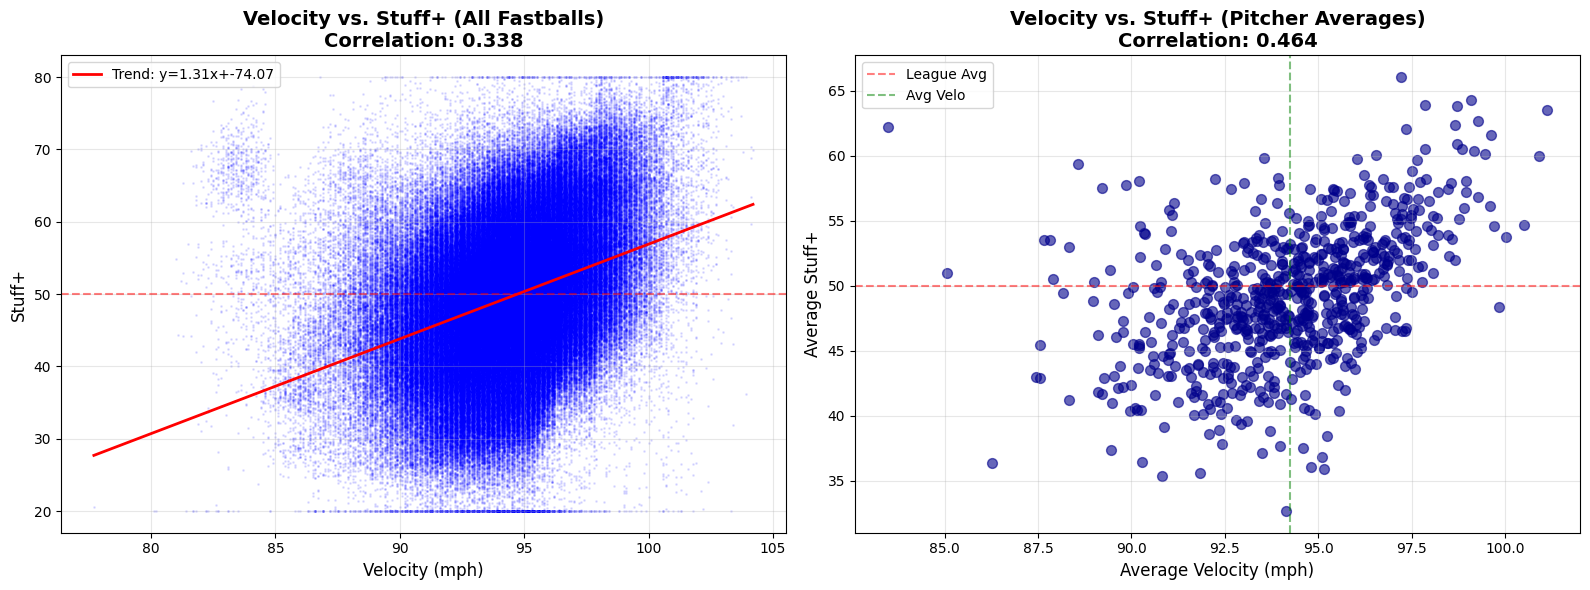


CRAFTY PITCHERS (High Stuff+ without elite velocity)
(Stuff+ >= 55, Velocity < 95 mph)

      player_name  avg_stuff_plus  avg_velocity  pitches
    Rogers, Tyler       62.202449     83.482473      736
     Díaz, Alexis       59.787799     93.555357      224
        Hill, Tim       59.372772     88.582653      882
  Sabrowski, Erik       58.288621     93.927485      342
    Hurter, Brant       58.240359     92.236395      588
   Bruihl, Justin       58.028019     90.200893      112
     Young, Danny       57.927363     93.016190      105
    Borucki, Ryan       57.756627     93.955215      163
   Thompson, Ryan       57.745383     89.851407      391
   Effross, Scott       57.540907     89.208235       85
  Peralta, Freddy       57.468394     94.779394     1650
      Vesia, Alex       57.401778     92.661897      601
   Kimbrel, Craig       56.685686     93.467114      149
McKenzie, Triston       56.365361     93.905085      118
     Kelly, Kevin       56.334400     91.152051      390

In [18]:
## 2. Velocity vs. Stuff+ Analysis

print("=" * 80)
print("VELOCITY vs. STUFF+ ANALYSIS - 2025")
print("=" * 80)
print()

# Analyze fastballs (FF and SI) - velocity matters most for these
fastball_types = ['FF', 'SI']
fastball_data = data_2025[data_2025['pitch_type'].isin(fastball_types)].copy()

if len(fastball_data) > 0:
    # Calculate correlation
    correlation = fastball_data['release_speed'].corr(fastball_data['stuff_plus'])
    print(f"Correlation between velocity and Stuff+ (Fastballs): {correlation:.3f}")
    print()

    # Create scatter plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: All fastballs
    axes[0].scatter(fastball_data['release_speed'], fastball_data['stuff_plus'],
                    alpha=0.1, s=1, c='blue')
    axes[0].set_xlabel('Velocity (mph)', fontsize=12)
    axes[0].set_ylabel('Stuff+', fontsize=12)
    axes[0].set_title(f'Velocity vs. Stuff+ (All Fastballs)\nCorrelation: {correlation:.3f}',
                      fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(50, color='red', linestyle='--', alpha=0.5)

    # Add trend line
    z = np.polyfit(fastball_data['release_speed'], fastball_data['stuff_plus'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(fastball_data['release_speed'].min(),
                         fastball_data['release_speed'].max(), 100)
    axes[0].plot(x_line, p(x_line), "r-", linewidth=2, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
    axes[0].legend()

    # Plot 2: Pitcher-level averages
    pitcher_velo = fastball_data.groupby(['pitcher', 'player_name']).agg(
        avg_velocity=('release_speed', 'mean'),
        avg_stuff_plus=('stuff_plus', 'mean'),
        pitches=('stuff_plus', 'count')
    ).reset_index()

    pitcher_velo = pitcher_velo[pitcher_velo['pitches'] >= 50]

    axes[1].scatter(pitcher_velo['avg_velocity'], pitcher_velo['avg_stuff_plus'],
                    alpha=0.6, s=50, c='darkblue')
    axes[1].set_xlabel('Average Velocity (mph)', fontsize=12)
    axes[1].set_ylabel('Average Stuff+', fontsize=12)

    pitcher_corr = pitcher_velo['avg_velocity'].corr(pitcher_velo['avg_stuff_plus'])
    axes[1].set_title(f'Velocity vs. Stuff+ (Pitcher Averages)\nCorrelation: {pitcher_corr:.3f}',
                      fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(50, color='red', linestyle='--', alpha=0.5, label='League Avg')
    axes[1].axvline(fastball_data['release_speed'].mean(), color='green',
                    linestyle='--', alpha=0.5, label='Avg Velo')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Elite stuff without elite velocity (crafty pitchers)
    print("\n" + "=" * 80)
    print("CRAFTY PITCHERS (High Stuff+ without elite velocity)")
    print("=" * 80)
    print("(Stuff+ >= 55, Velocity < 95 mph)")
    print()

    crafty = pitcher_velo[
        (pitcher_velo['avg_stuff_plus'] >= 55) &
        (pitcher_velo['avg_velocity'] < 95)
    ].sort_values('avg_stuff_plus', ascending=False).head(15)

    print(crafty[['player_name', 'avg_stuff_plus', 'avg_velocity', 'pitches']].to_string(index=False))

    # Hard throwers with elite stuff
    print("\n" + "=" * 80)
    print("POWER PITCHERS (Elite velocity + Elite stuff)")
    print("=" * 80)
    print("(Stuff+ >= 55, Velocity >= 97 mph)")
    print()

    power = pitcher_velo[
        (pitcher_velo['avg_stuff_plus'] >= 55) &
        (pitcher_velo['avg_velocity'] >= 97)
    ].sort_values('avg_stuff_plus', ascending=False).head(15)

    print(power[['player_name', 'avg_stuff_plus', 'avg_velocity', 'pitches']].to_string(index=False))
else:
    print("No fastball data available")

SPIN RATE vs. STUFF+ ANALYSIS - 2025



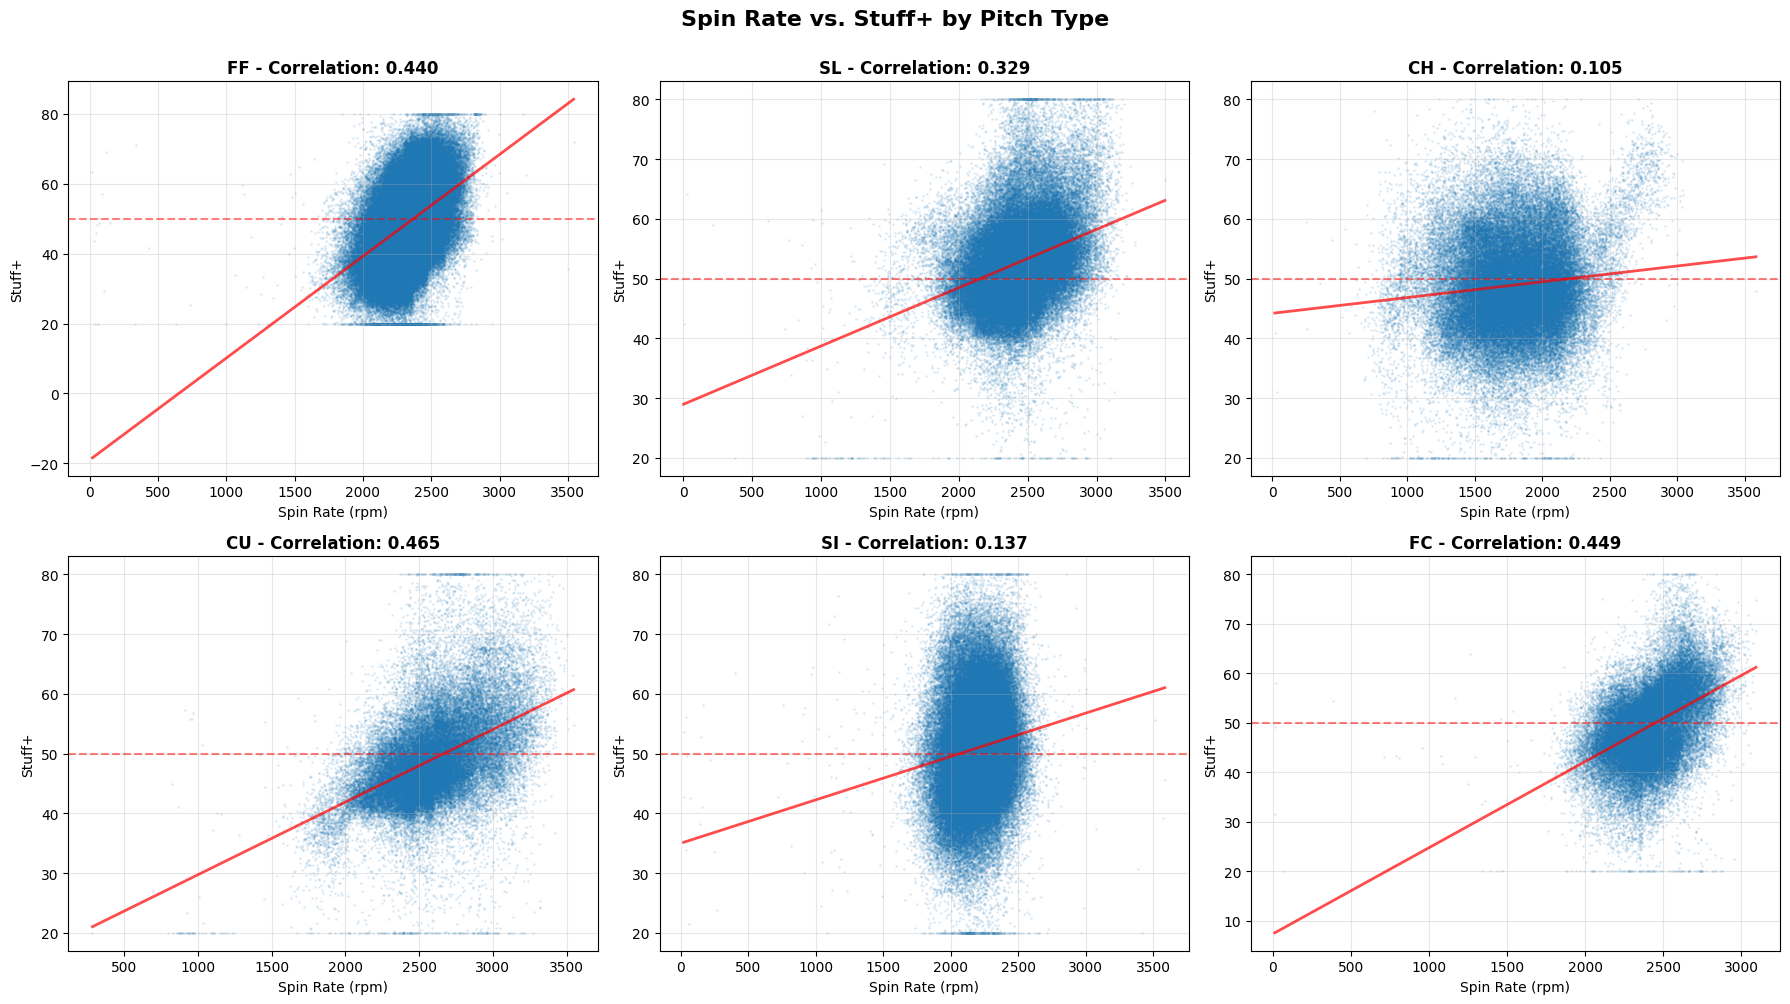


HIGH-SPIN MASTERS (Top spin rates with elite stuff)


Top 10 Fastball Spin Rates (with Stuff+ >= 52):
     player_name    avg_spin  avg_stuff_plus  pitches
       Kent, Zak 2761.611111       54.723961       90
Hollowell, Gavin 2717.519481       56.109747       77
    Bachar, Lake 2716.373272       54.678662      434
     Pérez, Eury 2684.541763       60.591468      862
Rodríguez, Randy 2653.460744       62.072499      484
Ribalta, Orlando 2645.497354       55.040704      189
 Sabrowski, Erik 2634.429825       58.288621      342
Núñez, Eduarniel 2630.387097       53.097764      155
 Kopech, Michael 2624.540984       58.816294      183
  Stewart, Brock 2620.049689       53.279296      322

Top 10 Slider Spin Rates (with Stuff+ >= 52):
         player_name    avg_spin  avg_stuff_plus  pitches
     Schmidt, Clarke 3037.246835       52.876697      158
         Brash, Matt 2949.836735       61.644631      490
    Ashcraft, Graham 2948.308489       68.626487      483
        Abreu, Bryan 292

In [19]:
## 3. Spin Rate Analysis

print("=" * 80)
print("SPIN RATE vs. STUFF+ ANALYSIS - 2025")
print("=" * 80)
print()

# Analyze spin rate by pitch type
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

pitch_types_spin = ['FF', 'SL', 'CH', 'CU', 'SI', 'FC']

for idx, pt in enumerate(pitch_types_spin):
    pt_data = data_2025[data_2025['pitch_type'] == pt].copy()

    if len(pt_data) > 0:
        correlation = pt_data['release_spin_rate'].corr(pt_data['stuff_plus'])

        axes[idx].scatter(pt_data['release_spin_rate'], pt_data['stuff_plus'],
                         alpha=0.1, s=1)
        axes[idx].set_xlabel('Spin Rate (rpm)', fontsize=10)
        axes[idx].set_ylabel('Stuff+', fontsize=10)
        axes[idx].set_title(f'{pt} - Correlation: {correlation:.3f}', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].axhline(50, color='red', linestyle='--', alpha=0.5)

        # Add trend line
        z = np.polyfit(pt_data['release_spin_rate'], pt_data['stuff_plus'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(pt_data['release_spin_rate'].min(),
                            pt_data['release_spin_rate'].max(), 100)
        axes[idx].plot(x_line, p(x_line), "r-", linewidth=2, alpha=0.7)

plt.suptitle('Spin Rate vs. Stuff+ by Pitch Type', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# High-spin masters
print("\n" + "=" * 80)
print("HIGH-SPIN MASTERS (Top spin rates with elite stuff)")
print("=" * 80)
print()

for pt in ['FF', 'SL', 'CU']:
    pt_data = data_2025[data_2025['pitch_type'] == pt].copy()

    if len(pt_data) > 0:
        pitcher_spin = pt_data.groupby(['pitcher', 'player_name']).agg(
            avg_spin=('release_spin_rate', 'mean'),
            avg_stuff_plus=('stuff_plus', 'mean'),
            pitches=('stuff_plus', 'count')
        ).reset_index()

        pitcher_spin = pitcher_spin[pitcher_spin['pitches'] >= 50]

        # Top spin rate with good stuff
        high_spin = pitcher_spin[
            pitcher_spin['avg_stuff_plus'] >= 52
        ].sort_values('avg_spin', ascending=False).head(10)

        pitch_name = {'FF': 'Fastball', 'SL': 'Slider', 'CU': 'Curveball'}
        print(f"\nTop 10 {pitch_name[pt]} Spin Rates (with Stuff+ >= 52):")
        print(high_spin[['player_name', 'avg_spin', 'avg_stuff_plus', 'pitches']].to_string(index=False))

# Low-spin effectiveness (pitchers who succeed without high spin)
print("\n" + "=" * 80)
print("LOW-SPIN EFFECTIVENESS (Elite stuff with below-average spin)")
print("=" * 80)
print()

for pt in ['FF', 'SI']:
    pt_data = data_2025[data_2025['pitch_type'] == pt].copy()

    if len(pt_data) > 0:
        median_spin = pt_data['release_spin_rate'].median()

        pitcher_spin = pt_data.groupby(['pitcher', 'player_name']).agg(
            avg_spin=('release_spin_rate', 'mean'),
            avg_stuff_plus=('stuff_plus', 'mean'),
            pitches=('stuff_plus', 'count')
        ).reset_index()

        pitcher_spin = pitcher_spin[pitcher_spin['pitches'] >= 50]

        # Low spin but elite stuff
        low_spin = pitcher_spin[
            (pitcher_spin['avg_spin'] < median_spin) &
            (pitcher_spin['avg_stuff_plus'] >= 55)
        ].sort_values('avg_stuff_plus', ascending=False).head(10)

        pitch_name = {'FF': 'Fastball', 'SI': 'Sinker'}
        print(f"\n{pitch_name[pt]} - Below-median spin ({median_spin:.0f} rpm) with Stuff+ >= 55:")
        if len(low_spin) > 0:
            print(low_spin[['player_name', 'avg_spin', 'avg_stuff_plus', 'pitches']].to_string(index=False))
        else:
            print("No pitchers meet criteria")

HANDEDNESS ANALYSIS - 2025

PITCHER HANDEDNESS COMPARISON
--------------------------------------------------------------------------------
          avg_stuff_plus  median_stuff_plus  pitches
p_throws                                            
R              50.468642          50.311991   530265
L              49.108830          49.002991   197519


PLATOON SPLITS (vs Same-Handed vs Opposite-Handed Batters)



/tmp/ipython-input-3665160825.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hand_comparison = data_2025.groupby('p_throws').agg(


Right-Handed Pitchers:
  vs RHB (same): Avg Stuff+ = 51.70 (266,514 pitches)
  vs LHB (opp):  Avg Stuff+ = 49.22 (263,751 pitches)

Left-Handed Pitchers:
  vs LHB (same): Avg Stuff+ = 53.43 (60,304 pitches)
  vs RHB (opp):  Avg Stuff+ = 47.21 (137,215 pitches)

BEST SAME-HANDED MATCHUP PITCHES


RHP vs RHB - Best Fastballs:
       player_name  avg_stuff_plus  pitches
 Estrada, Jeremiah       64.192117      403
Henriquez, Edgardo       64.071979       34
    Megill, Trevor       64.036726      210
     Miller, Mason       63.018287      296
     Taylor, Grant       62.740109      148

RHP vs RHB - Best Sliders:
     player_name  avg_stuff_plus  pitches
   Peguero, Joel       74.699632       71
   Taylor, Grant       70.539985       39
   Helsley, Ryan       69.839006      272
    Burns, Chase       68.552866      156
Ashcraft, Graham       67.998627      296

RHP vs RHB - Best Changeups:
     player_name  avg_stuff_plus  pitches
 Williams, Devin       67.193287      353
Birdsong, Hayden

/tmp/ipython-input-3665160825.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rhp_splits = rhp_data.groupby(['pitch_type', 'stand']).agg(
/tmp/ipython-input-3665160825.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lhp_splits = lhp_data.groupby(['pitch_type', 'stand']).agg(


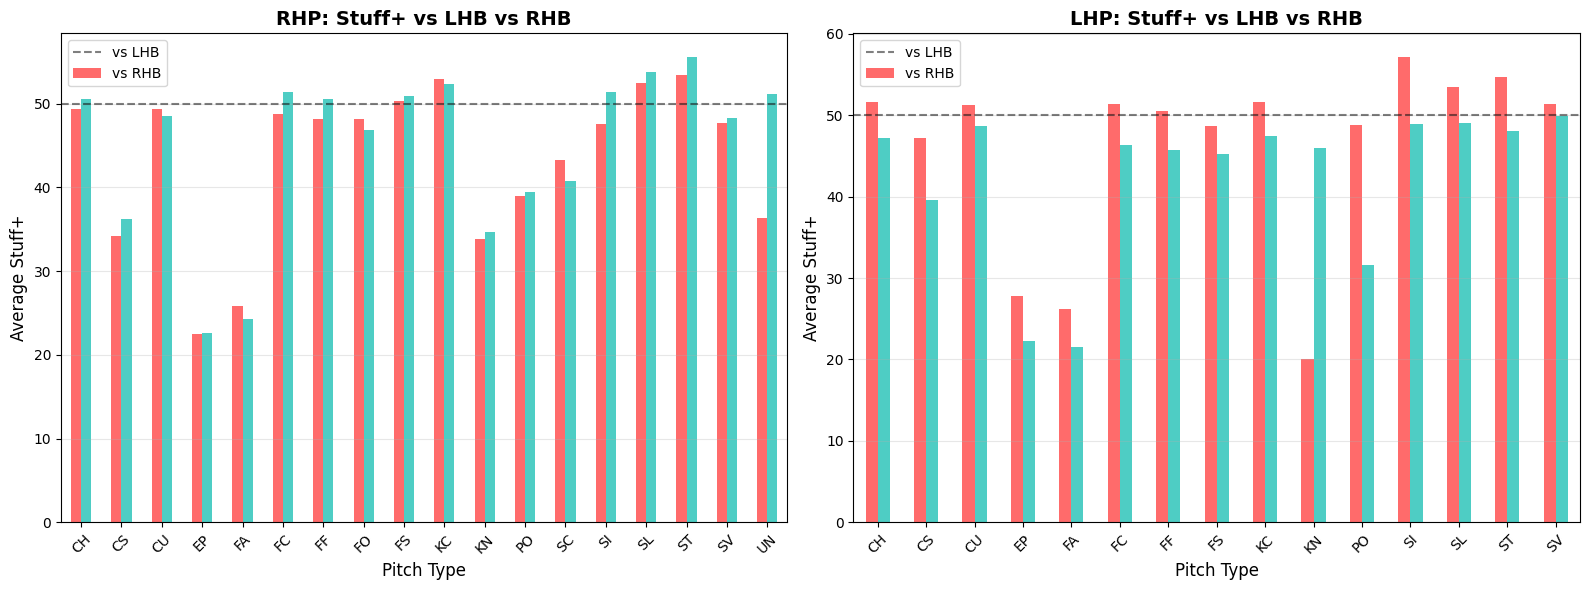

In [20]:
## 4. Handedness Splits Analysis

print("=" * 80)
print("HANDEDNESS ANALYSIS - 2025")
print("=" * 80)
print()

# Overall RHP vs LHP
print("PITCHER HANDEDNESS COMPARISON")
print("-" * 80)
hand_comparison = data_2025.groupby('p_throws').agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    median_stuff_plus=('stuff_plus', 'median'),
    pitches=('stuff_plus', 'count')
)
print(hand_comparison)
print()

# Platoon advantage analysis (same-handed matchups)
print("\n" + "=" * 80)
print("PLATOON SPLITS (vs Same-Handed vs Opposite-Handed Batters)")
print("=" * 80)
print()

# RHP vs RHB (same) and RHP vs LHB (opposite)
rhp_vs_rhb = data_2025[(data_2025['p_throws'] == 'R') & (data_2025['stand'] == 'R')]
rhp_vs_lhb = data_2025[(data_2025['p_throws'] == 'R') & (data_2025['stand'] == 'L')]

# LHP vs LHB (same) and LHP vs RHB (opposite)
lhp_vs_lhb = data_2025[(data_2025['p_throws'] == 'L') & (data_2025['stand'] == 'L')]
lhp_vs_rhb = data_2025[(data_2025['p_throws'] == 'L') & (data_2025['stand'] == 'R')]

print("Right-Handed Pitchers:")
print(f"  vs RHB (same): Avg Stuff+ = {rhp_vs_rhb['stuff_plus'].mean():.2f} ({len(rhp_vs_rhb):,} pitches)")
print(f"  vs LHB (opp):  Avg Stuff+ = {rhp_vs_lhb['stuff_plus'].mean():.2f} ({len(rhp_vs_lhb):,} pitches)")
print()
print("Left-Handed Pitchers:")
print(f"  vs LHB (same): Avg Stuff+ = {lhp_vs_lhb['stuff_plus'].mean():.2f} ({len(lhp_vs_lhb):,} pitches)")
print(f"  vs RHB (opp):  Avg Stuff+ = {lhp_vs_rhb['stuff_plus'].mean():.2f} ({len(lhp_vs_rhb):,} pitches)")

# Best same-handed matchup pitches by type
print("\n" + "=" * 80)
print("BEST SAME-HANDED MATCHUP PITCHES")
print("=" * 80)
print()

for pt in ['FF', 'SL', 'CH', 'CU']:
    # RHP vs RHB
    rhp_same = data_2025[
        (data_2025['p_throws'] == 'R') &
        (data_2025['stand'] == 'R') &
        (data_2025['pitch_type'] == pt)
    ]

    if len(rhp_same) > 0:
        rhp_same_leaders = rhp_same.groupby(['pitcher', 'player_name']).agg(
            avg_stuff_plus=('stuff_plus', 'mean'),
            pitches=('stuff_plus', 'count')
        ).reset_index()

        rhp_same_leaders = rhp_same_leaders[rhp_same_leaders['pitches'] >= 30]
        rhp_same_leaders = rhp_same_leaders.sort_values('avg_stuff_plus', ascending=False).head(5)

        pitch_name = {'FF': 'Fastball', 'SL': 'Slider', 'CH': 'Changeup', 'CU': 'Curveball'}
        print(f"\nRHP vs RHB - Best {pitch_name[pt]}s:")
        print(rhp_same_leaders[['player_name', 'avg_stuff_plus', 'pitches']].to_string(index=False))

# Visualize platoon splits by pitch type
print("\n" + "=" * 80)
print("PLATOON SPLITS BY PITCH TYPE")
print("=" * 80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# RHP splits
rhp_data = data_2025[data_2025['p_throws'] == 'R']
rhp_splits = rhp_data.groupby(['pitch_type', 'stand']).agg(
    avg_stuff_plus=('stuff_plus', 'mean')
).reset_index()

rhp_pivot = rhp_splits.pivot(index='pitch_type', columns='stand', values='avg_stuff_plus')
rhp_pivot.plot(kind='bar', ax=ax1, color=['#FF6B6B', '#4ECDC4'])
ax1.set_title('RHP: Stuff+ vs LHB vs RHB', fontsize=14, fontweight='bold')
ax1.set_xlabel('Pitch Type', fontsize=12)
ax1.set_ylabel('Average Stuff+', fontsize=12)
ax1.axhline(50, color='black', linestyle='--', alpha=0.5)
ax1.legend(['vs LHB', 'vs RHB'])
ax1.grid(axis='y', alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# LHP splits
lhp_data = data_2025[data_2025['p_throws'] == 'L']
lhp_splits = lhp_data.groupby(['pitch_type', 'stand']).agg(
    avg_stuff_plus=('stuff_plus', 'mean')
).reset_index()

lhp_pivot = lhp_splits.pivot(index='pitch_type', columns='stand', values='avg_stuff_plus')
lhp_pivot.plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4'])
ax2.set_title('LHP: Stuff+ vs LHB vs RHB', fontsize=14, fontweight='bold')
ax2.set_xlabel('Pitch Type', fontsize=12)
ax2.set_ylabel('Average Stuff+', fontsize=12)
ax2.axhline(50, color='black', linestyle='--', alpha=0.5)
ax2.legend(['vs LHB', 'vs RHB'])
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

STUFF+ CONSISTENCY ANALYSIS - 2025

Measuring game-to-game variability in Stuff+

MOST CONSISTENT PITCHERS (Low game-to-game variance)
(Minimum 5 games, sorted by lowest standard deviation)

      player_name  mean_stuff_plus  std_stuff_plus  games  total_pitches
   Sanoja, Javier        20.014190        0.034758      6            157
    Chavez, Jesse        43.131015        0.423727      5            192
      Davis, Noah        47.516366        0.602128      8            250
 Williams, Trevor        45.156334        0.651829     17           1448
   Peralta, Sammy        48.902264        0.674494      5            153
    VanWey, Logan        49.295640        0.734898      9            200
  Mederos, Victor        51.023062        0.790288      5            314
  Lawrence, Casey        42.625510        0.883910      5            268
       Meyer, Max        53.012213        0.946457     13           1090
    Feltner, Ryan        46.452766        0.968422      7            597
      

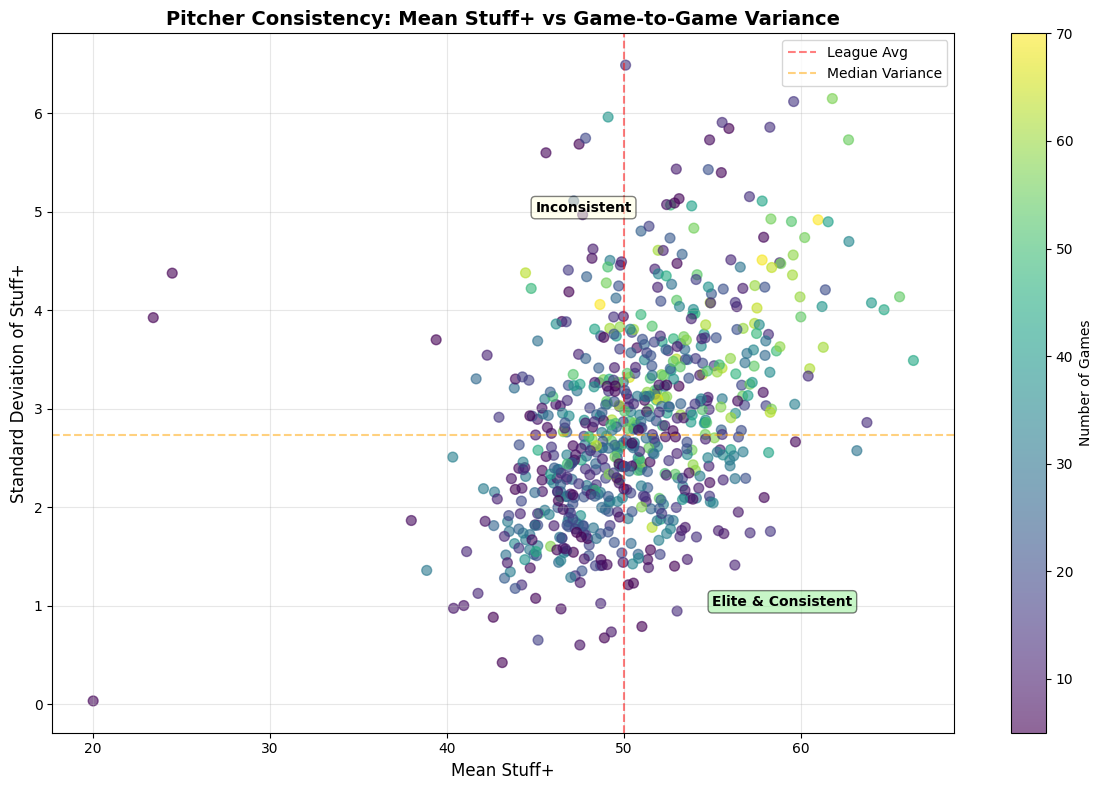

In [21]:
## 5. Stuff+ Consistency Analysis

print("=" * 80)
print("STUFF+ CONSISTENCY ANALYSIS - 2025")
print("=" * 80)
print()
print("Measuring game-to-game variability in Stuff+")
print()

# Calculate game-by-game Stuff+ for each pitcher
pitcher_game_stats = data_2025.groupby(['pitcher', 'player_name', 'game_date']).agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
).reset_index()

# Filter for games with at least 10 pitches
pitcher_game_stats = pitcher_game_stats[pitcher_game_stats['pitches'] >= 10]

# Calculate consistency metrics per pitcher
consistency_stats = pitcher_game_stats.groupby(['pitcher', 'player_name']).agg(
    mean_stuff_plus=('avg_stuff_plus', 'mean'),
    std_stuff_plus=('avg_stuff_plus', 'std'),
    games=('game_date', 'count'),
    total_pitches=('pitches', 'sum')
).reset_index()

# Filter for pitchers with 5+ games
consistency_stats = consistency_stats[consistency_stats['games'] >= 5]

# Calculate coefficient of variation (lower = more consistent)
consistency_stats['cv'] = consistency_stats['std_stuff_plus'] / consistency_stats['mean_stuff_plus']
consistency_stats['consistency_score'] = 100 - (consistency_stats['cv'] * 100)

# Most consistent pitchers (low std dev, high mean)
print("=" * 80)
print("MOST CONSISTENT PITCHERS (Low game-to-game variance)")
print("=" * 80)
print("(Minimum 5 games, sorted by lowest standard deviation)")
print()

most_consistent = consistency_stats.sort_values('std_stuff_plus').head(20)
print(most_consistent[['player_name', 'mean_stuff_plus', 'std_stuff_plus', 'games', 'total_pitches']].to_string(index=False))

# Least consistent pitchers (high variance)
print("\n" + "=" * 80)
print("MOST VOLATILE PITCHERS (High game-to-game variance)")
print("=" * 80)
print("(Minimum 5 games, sorted by highest standard deviation)")
print()

least_consistent = consistency_stats.sort_values('std_stuff_plus', ascending=False).head(20)
print(least_consistent[['player_name', 'mean_stuff_plus', 'std_stuff_plus', 'games', 'total_pitches']].to_string(index=False))

# Consistent elite pitchers (high mean + low variance)
print("\n" + "=" * 80)
print("CONSISTENTLY ELITE PITCHERS")
print("=" * 80)
print("(Mean Stuff+ >= 52, Std Dev < 3.0)")
print()

elite_consistent = consistency_stats[
    (consistency_stats['mean_stuff_plus'] >= 52) &
    (consistency_stats['std_stuff_plus'] < 3.0)
].sort_values('mean_stuff_plus', ascending=False).head(15)

print(elite_consistent[['player_name', 'mean_stuff_plus', 'std_stuff_plus', 'games']].to_string(index=False))

# Visualization: Mean vs Std Dev
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(consistency_stats['mean_stuff_plus'],
                     consistency_stats['std_stuff_plus'],
                     alpha=0.6, s=50, c=consistency_stats['games'],
                     cmap='viridis')

ax.set_xlabel('Mean Stuff+', fontsize=12)
ax.set_ylabel('Standard Deviation of Stuff+', fontsize=12)
ax.set_title('Pitcher Consistency: Mean Stuff+ vs Game-to-Game Variance',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='League Avg')
ax.axhline(consistency_stats['std_stuff_plus'].median(), color='orange',
           linestyle='--', alpha=0.5, label='Median Variance')

# Add quadrant labels
ax.text(55, 1, 'Elite & Consistent', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax.text(45, 5, 'Inconsistent', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Number of Games', fontsize=10)
ax.legend()

plt.tight_layout()
plt.show()

STUFF+ vs. USAGE ANALYSIS - 2025

Do pitchers throw their best pitches more often?

Correlation between Stuff+ and Usage%: 0.229



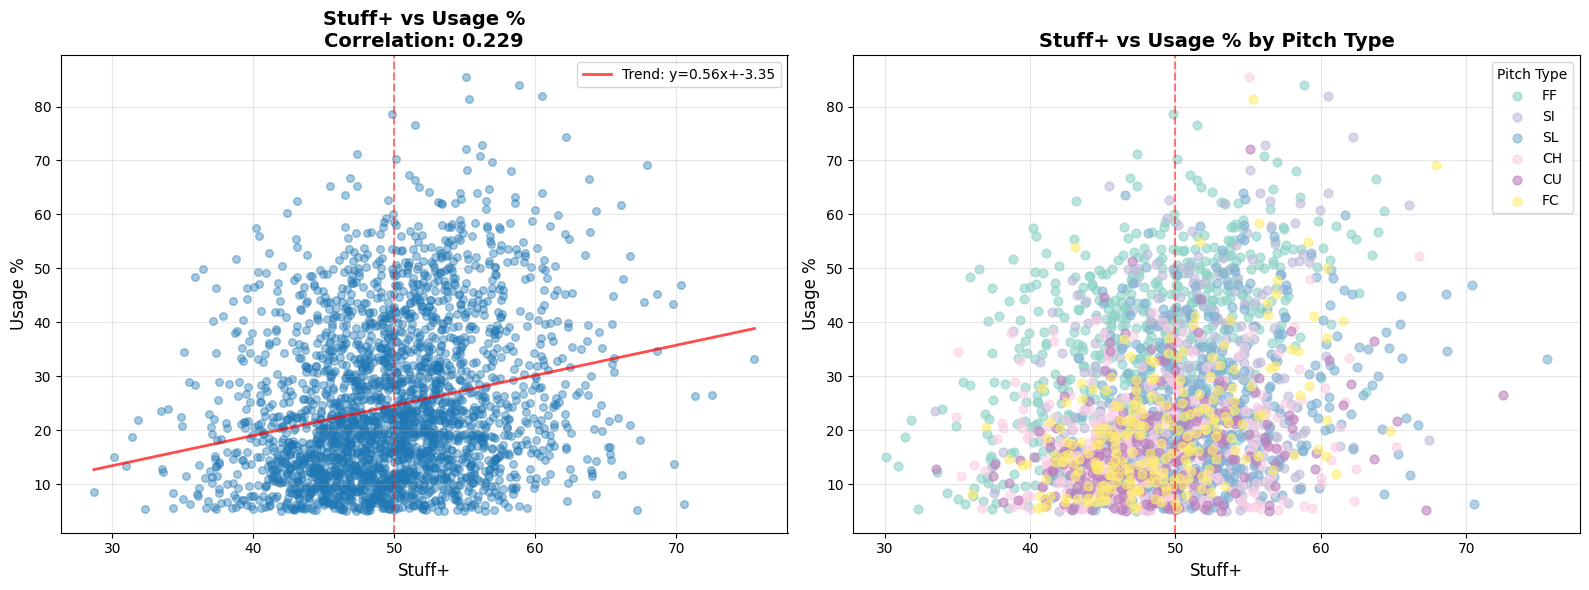


UNDERUTILIZED ELITE PITCHES
(Stuff+ >= 58, Usage < 20%)

        player_name pitch_type  avg_stuff_plus  usage_pct  pitch_count  total_pitches
      Taylor, Grant         SL       70.539985   6.393443           39            610
        Leahy, Kyle         ST       69.829050  13.742690          188           1368
       Miller, Erik         SI       67.447870  18.253968           92            504
     Alvarado, José         CU       67.241590   5.210421           26            499
 Henriquez, Edgardo         SL       66.131307  11.627907           30            258
       Keller, Brad         ST       65.389062  14.465409          161           1113
       García, Yimi         ST       65.312441  16.886544           64            379
   Chapman, Aroldis         SL       65.278084  15.557940          145            932
   Birdsong, Hayden         CH       65.179862  16.834171          201           1194
    Schlittler, Cam         FC       64.716899  19.923664          261           1

/tmp/ipython-input-372310970.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_usage = pitcher_usage.groupby('stuff_tier').agg(


In [22]:
## 6. Stuff+ vs. Usage Analysis

print("=" * 80)
print("STUFF+ vs. USAGE ANALYSIS - 2025")
print("=" * 80)
print()
print("Do pitchers throw their best pitches more often?")
print()

# Calculate usage percentage for each pitcher-pitch combination
pitcher_usage = data_2025.groupby(['pitcher', 'player_name', 'pitch_type']).agg(
    pitch_count=('pitch_type', 'count'),
    avg_stuff_plus=('stuff_plus', 'mean')
).reset_index()

# Get total pitches per pitcher
pitcher_totals = data_2025.groupby('pitcher').size().reset_index(name='total_pitches')

# Merge and calculate usage percentage
pitcher_usage = pitcher_usage.merge(pitcher_totals, on='pitcher')
pitcher_usage['usage_pct'] = (pitcher_usage['pitch_count'] / pitcher_usage['total_pitches']) * 100

# Filter for pitchers with 200+ total pitches
pitcher_usage = pitcher_usage[pitcher_usage['total_pitches'] >= 200]

# Filter for pitches used at least 5% of the time
pitcher_usage = pitcher_usage[pitcher_usage['usage_pct'] >= 5.0]

# Calculate correlation
correlation = pitcher_usage['avg_stuff_plus'].corr(pitcher_usage['usage_pct'])
print(f"Correlation between Stuff+ and Usage%: {correlation:.3f}")
print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Overall scatter
axes[0].scatter(pitcher_usage['avg_stuff_plus'], pitcher_usage['usage_pct'],
                alpha=0.4, s=30)
axes[0].set_xlabel('Stuff+', fontsize=12)
axes[0].set_ylabel('Usage %', fontsize=12)
axes[0].set_title(f'Stuff+ vs Usage %\nCorrelation: {correlation:.3f}',
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(50, color='red', linestyle='--', alpha=0.5)

# Add trend line
z = np.polyfit(pitcher_usage['avg_stuff_plus'], pitcher_usage['usage_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(pitcher_usage['avg_stuff_plus'].min(),
                     pitcher_usage['avg_stuff_plus'].max(), 100)
axes[0].plot(x_line, p(x_line), "r-", linewidth=2, alpha=0.7,
             label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
axes[0].legend()

# Plot 2: By pitch type
pitch_types_usage = ['FF', 'SI', 'SL', 'CH', 'CU', 'FC']
colors = plt.cm.Set3(np.linspace(0, 1, len(pitch_types_usage)))

for idx, pt in enumerate(pitch_types_usage):
    pt_data = pitcher_usage[pitcher_usage['pitch_type'] == pt]
    if len(pt_data) > 0:
        axes[1].scatter(pt_data['avg_stuff_plus'], pt_data['usage_pct'],
                       alpha=0.6, s=40, label=pt, color=colors[idx])

axes[1].set_xlabel('Stuff+', fontsize=12)
axes[1].set_ylabel('Usage %', fontsize=12)
axes[1].set_title('Stuff+ vs Usage % by Pitch Type', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(50, color='red', linestyle='--', alpha=0.5)
axes[1].legend(title='Pitch Type', loc='best')

plt.tight_layout()
plt.show()

# Underutilized elite pitches
print("\n" + "=" * 80)
print("UNDERUTILIZED ELITE PITCHES")
print("=" * 80)
print("(Stuff+ >= 58, Usage < 20%)")
print()

underutilized = pitcher_usage[
    (pitcher_usage['avg_stuff_plus'] >= 58) &
    (pitcher_usage['usage_pct'] < 20)
].sort_values('avg_stuff_plus', ascending=False).head(20)

print(underutilized[['player_name', 'pitch_type', 'avg_stuff_plus', 'usage_pct',
                     'pitch_count', 'total_pitches']].to_string(index=False))

# Over-relied pitches (high usage, below average stuff)
print("\n" + "=" * 80)
print("OVER-RELIED PITCHES")
print("=" * 80)
print("(Stuff+ < 48, Usage > 30%)")
print()

overrelied = pitcher_usage[
    (pitcher_usage['avg_stuff_plus'] < 48) &
    (pitcher_usage['usage_pct'] > 30)
].sort_values('usage_pct', ascending=False).head(20)

print(overrelied[['player_name', 'pitch_type', 'avg_stuff_plus', 'usage_pct',
                  'pitch_count', 'total_pitches']].to_string(index=False))

# Optimal usage (high stuff, high usage)
print("\n" + "=" * 80)
print("OPTIMAL USAGE")
print("=" * 80)
print("(Stuff+ >= 58, Usage >= 30%)")
print()

optimal = pitcher_usage[
    (pitcher_usage['avg_stuff_plus'] >= 58) &
    (pitcher_usage['usage_pct'] >= 30)
].sort_values('avg_stuff_plus', ascending=False).head(15)

print(optimal[['player_name', 'pitch_type', 'avg_stuff_plus', 'usage_pct',
               'pitch_count']].to_string(index=False))

# Usage breakdown by stuff tier
print("\n" + "=" * 80)
print("AVERAGE USAGE BY STUFF+ TIER")
print("=" * 80)

pitcher_usage['stuff_tier'] = pd.cut(pitcher_usage['avg_stuff_plus'],
                                      bins=[0, 45, 50, 55, 60, 100],
                                      labels=['Poor (<45)', 'Below Avg (45-50)',
                                             'Above Avg (50-55)', 'Plus (55-60)',
                                             'Elite (60+)'])

tier_usage = pitcher_usage.groupby('stuff_tier').agg(
    avg_usage=('usage_pct', 'mean'),
    median_usage=('usage_pct', 'median'),
    count=('usage_pct', 'count')
)

print(tier_usage)

In [23]:
## Summary Statistics

print("=" * 80)
print("2025 STUFF+ ANALYSIS SUMMARY")
print("=" * 80)
print()
print(f"Total pitches analyzed: {len(data_2025):,}")
print(f"Overall Stuff+ mean: {data_2025['stuff_plus'].mean():.2f}")
print(f"Overall Stuff+ std: {data_2025['stuff_plus'].std():.2f}")
print()
print("By Role:")
role_summary = data_2025.groupby('role').agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
)
print(role_summary)
print()
print("By Pitch Type:")
pitch_type_summary = data_2025.groupby('pitch_type').agg(
    avg_stuff_plus=('stuff_plus', 'mean'),
    pitches=('stuff_plus', 'count')
).sort_values('avg_stuff_plus', ascending=False)
print(pitch_type_summary)
print()
print("Leaderboard Coverage:")
print(f"  - Qualified SPs (200+ pitches): {len(sp_leaderboard)}")
print(f"  - Qualified RPs (100+ pitches): {len(rp_leaderboard)}")
print(f"  - Qualified pitch-type combos (50+ pitches): {len(pitch_leaderboard)}")

2025 STUFF+ ANALYSIS SUMMARY

Total pitches analyzed: 727,784
Overall Stuff+ mean: 50.10
Overall Stuff+ std: 9.35

By Role:
      avg_stuff_plus  pitches
role                         
RP         51.446989   316728
SP         49.061391   411056

By Pitch Type:
            avg_stuff_plus  pitches
pitch_type                         
ST               53.969582    50855
SL               52.691975   107719
KC               51.843340    12091
SI               50.868315   113594
FS               49.991065    24040
FC               49.402660    55230
CU               49.094329    51326
CH               48.888848    74805
SV               48.728771     3606
FF               48.638490   231558
FO               47.615485      539
SC               42.565451        7
UN               41.252568        3
PO               39.037162       55
CS               37.385565      359
KN               34.422609      139
FA               24.745543      903
EP               22.603205      955

Leaderboard Coverag